# Análisis Exploratorio de Datos — WISDM HAR

**Objetivo:** Entender el dataset antes de construir cualquier modelo.  
El EDA responde tres preguntas clave:
1. ¿Están balanceadas las clases?
2. ¿Cómo se ven las señales por actividad?
3. ¿Son las clases linealmente separables?

Las respuestas justifican las decisiones de modelado posteriores.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from src.data_loader import load_dataset, load_activity_labels
from src.features import extract_features_from_windows

RANDOM_STATE = 42
FIGURES_DIR = Path('..') / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')
print('Setup OK')

Setup OK


## 1. Carga de datos

In [2]:
X_train, y_train = load_dataset('train')
X_test,  y_test  = load_dataset('test')
labels = load_activity_labels()

print(f'X_train : {X_train.shape}  → (muestras, timesteps, ejes_acelerometro)')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}  — clases: {sorted(np.unique(y_train))}')
print(f'dtype   : {X_train.dtype}')
print(f'\nActividades: {labels}')
print(f'\nTotal muestras: {len(y_train) + len(y_test):,}')
print(f'Memoria (X_train): {X_train.nbytes / 1e6:.1f} MB')

X_train : (43924, 90, 3)  → (muestras, timesteps, ejes_acelerometro)
X_test  : (10982, 90, 3)
y_train : (43924,)  — clases: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
dtype   : float32

Actividades: {0: 'Walking', 1: 'Jogging', 2: 'Sitting', 3: 'Standing', 4: 'Upstairs', 5: 'Downstairs'}

Total muestras: 54,906
Memoria (X_train): 47.4 MB


## 2. Distribución de clases

Lo primero que hay que verificar en cualquier problema de clasificación:
¿están las clases balanceadas? Si no lo están, **accuracy** puede ser engañosa.

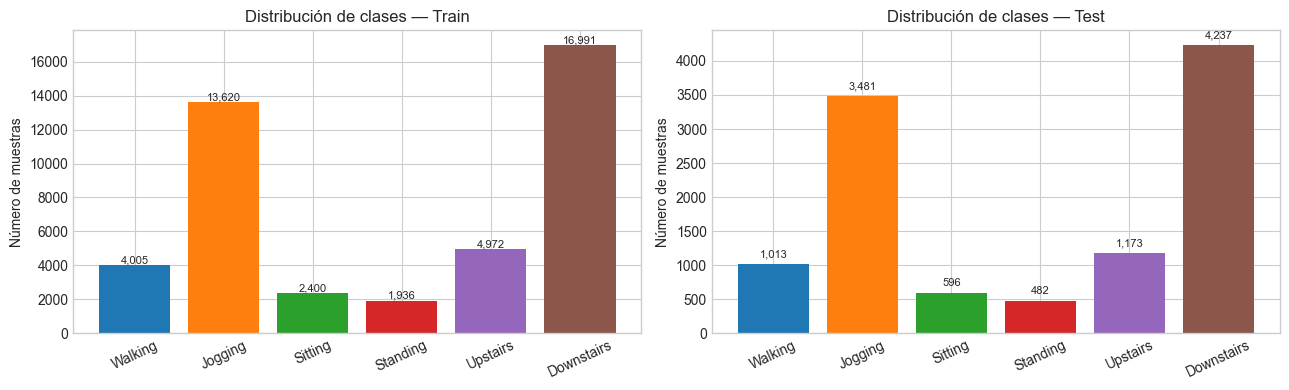

Porcentaje por clase (train):
  Walking     : 9.1%
  Jogging     : 31.0%
  Sitting     : 5.5%
  Standing    : 4.4%
  Upstairs    : 11.3%
  Downstairs  : 38.7%

→ Dataset DESBALANCEADO: Jogging y Downstairs representan el 70% del dataset.
→ Usaremos F1-macro como métrica principal (promedia F1 por clase sin ponderar).


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = sns.color_palette('tab10', 6)

for ax, (split_y, title) in zip(axes, [(y_train, 'Train'), (y_test, 'Test')]):
    counts = [int(np.sum(split_y == k)) for k in sorted(labels)]
    activity_names = [labels[k] for k in sorted(labels)]
    bars = ax.bar(activity_names, counts, color=colors)
    ax.set_title(f'Distribución de clases — {title}', fontsize=12)
    ax.set_ylabel('Número de muestras')
    ax.tick_params(axis='x', rotation=25)
    for bar, v in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{v:,}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Mostrar porcentajes
print('Porcentaje por clase (train):')
for k in sorted(labels):
    pct = np.sum(y_train == k) / len(y_train) * 100
    print(f'  {labels[k]:12s}: {pct:.1f}%')

print('\n→ Dataset DESBALANCEADO: Jogging y Downstairs representan el 70% del dataset.')
print('→ Usaremos F1-macro como métrica principal (promedia F1 por clase sin ponderar).')

## 3. Visualización de señales

Cada muestra es una **ventana de 90 timesteps** (≈2.25 segundos a 40 Hz)  
con 3 canales: acelerómetro X, Y, Z.

Visualizar señales reales antes de modelar ayuda a:
- Detectar ruido, valores atípicos o problemas en los datos
- Entender qué hace diferente a cada actividad en el dominio temporal

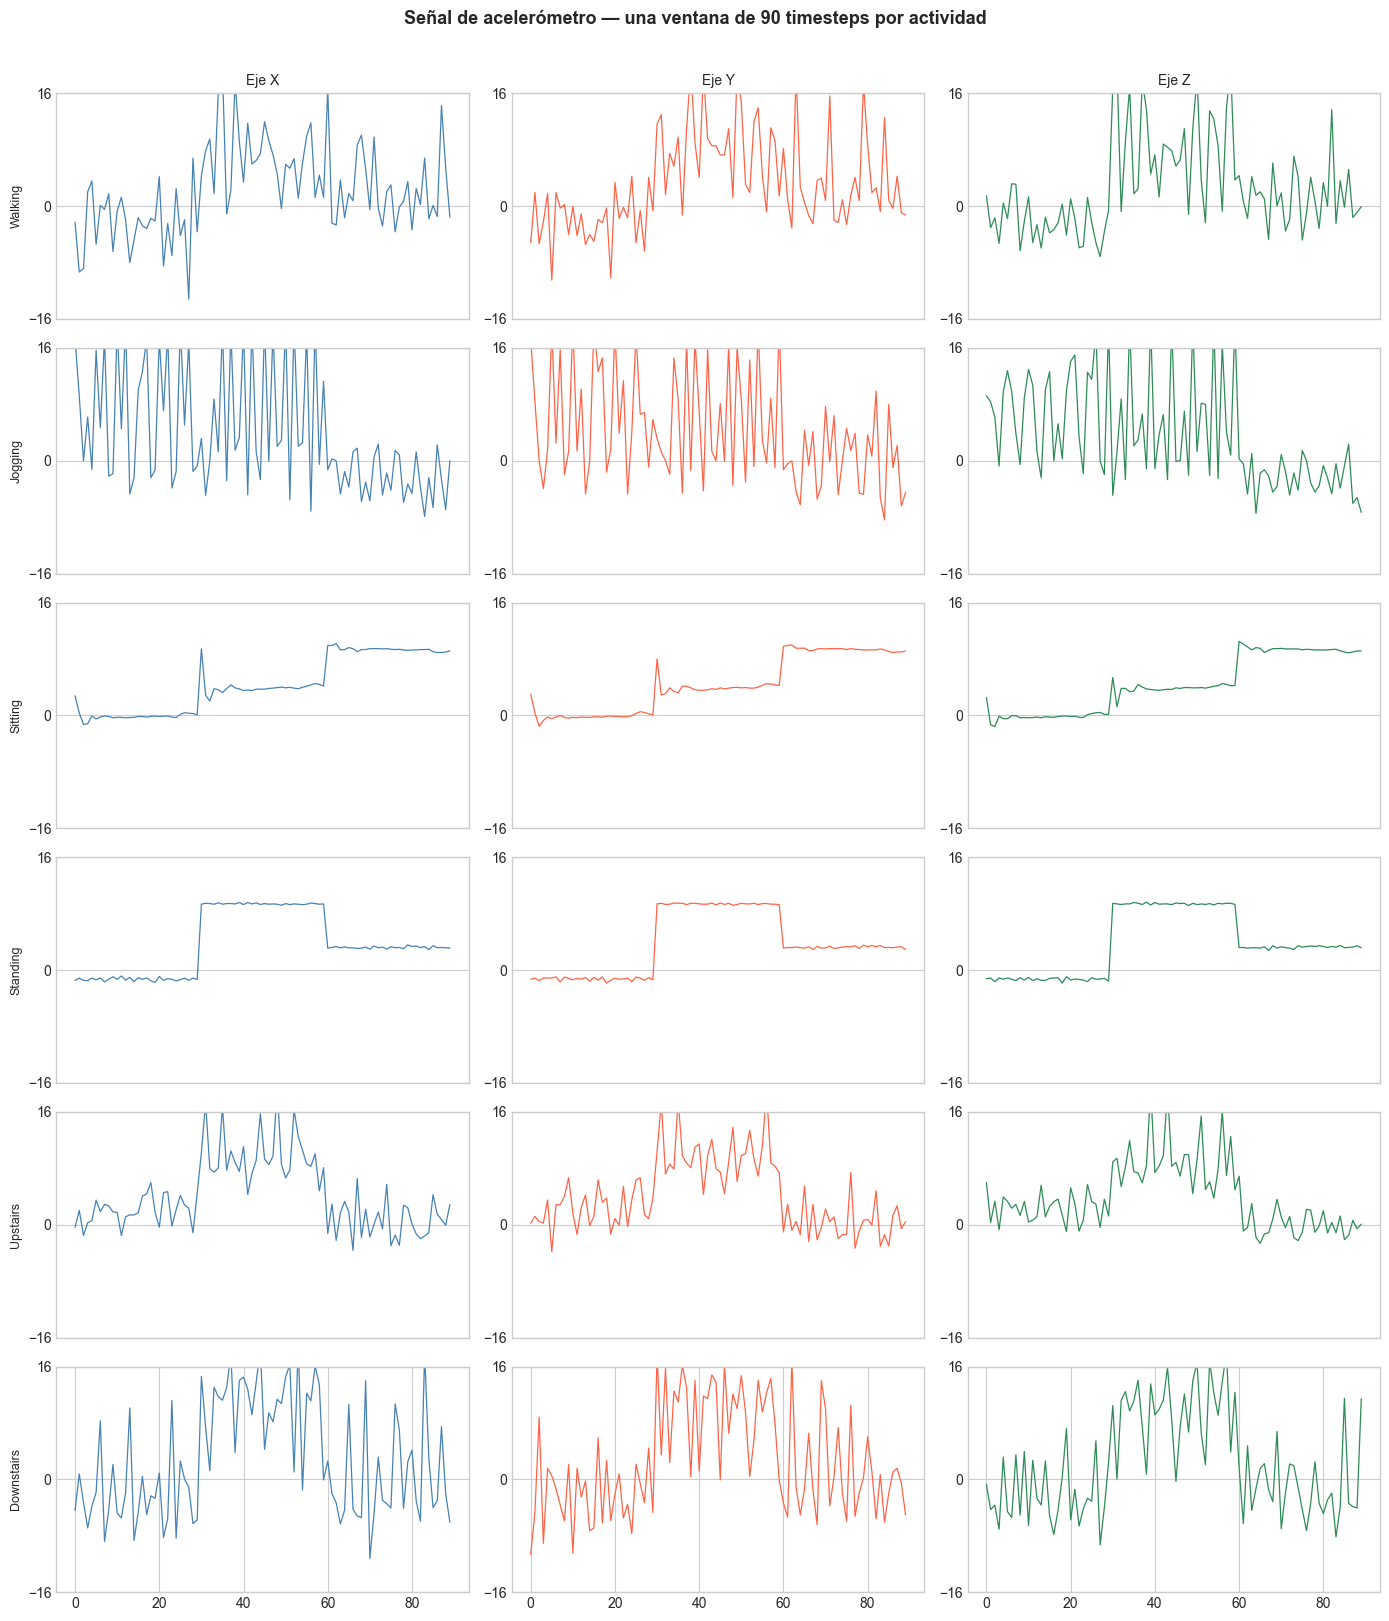

Observaciones:
  Jogging  → alta amplitud, patrón periódico claro
  Walking  → amplitud media, periodicidad más lenta
  Sitting/Standing → señal casi constante (baja varianza)
  Upstairs/Downstairs → patrón intermedio, similar entre sí


In [8]:
fig, axes = plt.subplots(6, 3, figsize=(14, 16))
axis_labels = ['Eje X', 'Eje Y', 'Eje Z']
colors_axes = ['steelblue', 'tomato', 'seagreen']

for row, act_id in enumerate(sorted(labels)):
    mask = y_train == act_id
    sample = X_train[mask][0]  # primera ventana de esa actividad
    for col in range(3):
        axes[row, col].plot(sample[:, col], color=colors_axes[col], linewidth=0.9)
        axes[row, col].set_ylim(-16, 16)
        axes[row, col].set_yticks([-16, 0, 16])
        if col == 0:
            axes[row, col].set_ylabel(labels[act_id], fontsize=9, rotation=90)
        if row == 0:
            axes[row, col].set_title(axis_labels[col], fontsize=10)
        if row < 5:
            axes[row, col].set_xticks([])

plt.suptitle('Señal de acelerómetro — una ventana de 90 timesteps por actividad',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sample_signals.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observaciones:')
print('  Jogging  → alta amplitud, patrón periódico claro')
print('  Walking  → amplitud media, periodicidad más lenta')
print('  Sitting/Standing → señal casi constante (baja varianza)')
print('  Upstairs/Downstairs → patrón intermedio, similar entre sí')

## 4. Magnitud del acelerómetro por actividad

La **magnitud** |acc| = √(x² + y² + z²) resume las 3 dimensiones en una sola.  
Ver la media ± desviación estándar sobre todas las muestras de cada clase.

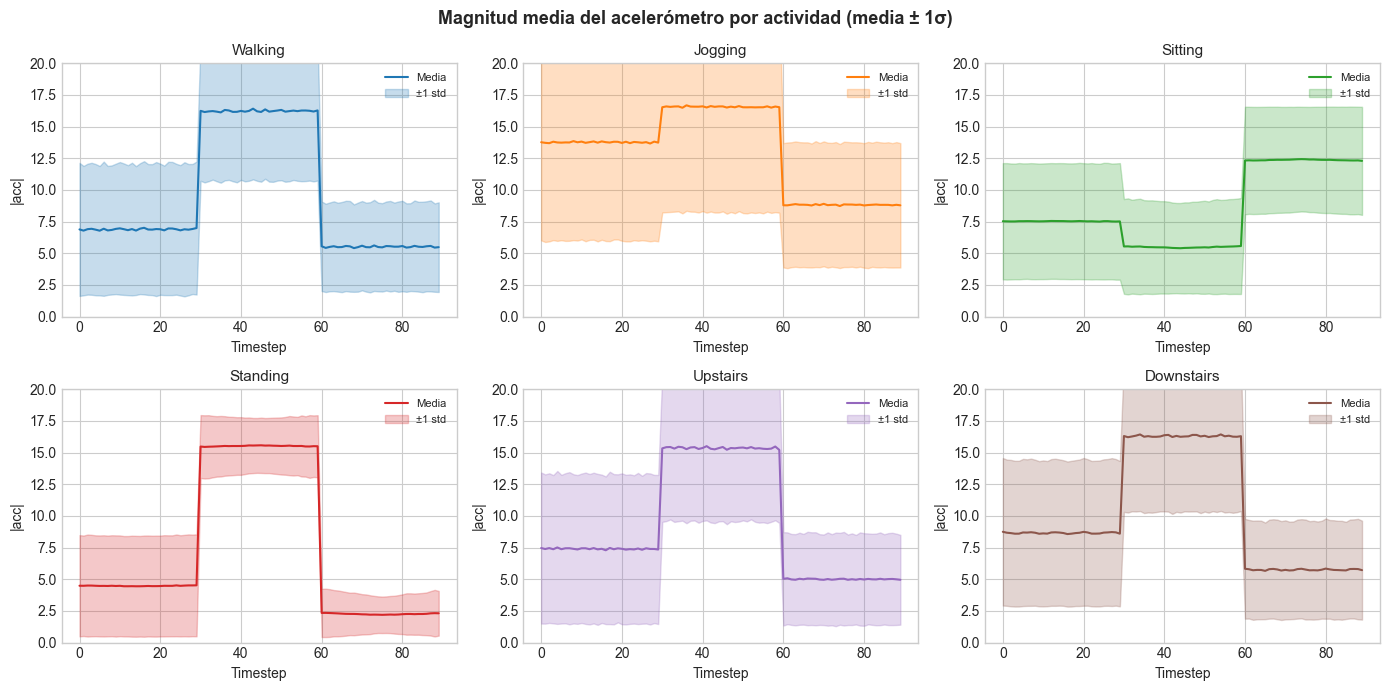

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
t = np.arange(90)

for idx, act_id in enumerate(sorted(labels)):
    ax = axes[idx // 3, idx % 3]
    mask = y_train == act_id
    signals = X_train[mask]           # (n, 90, 3)
    magnitude = np.sqrt((signals**2).sum(axis=2))  # (n, 90)
    mean_mag = magnitude.mean(axis=0)
    std_mag  = magnitude.std(axis=0)

    ax.plot(t, mean_mag, color=colors[idx], linewidth=1.5, label='Media')
    ax.fill_between(t, mean_mag - std_mag, mean_mag + std_mag,
                    alpha=0.25, color=colors[idx], label='±1 std')
    ax.set_title(labels[act_id], fontsize=11)
    ax.set_ylim(0, 20)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('|acc|')
    ax.legend(fontsize=8)

plt.suptitle('Magnitud media del acelerómetro por actividad (media ± 1σ)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'mean_magnitude.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Separabilidad: PCA y t-SNE

Antes de modelar, queremos saber **qué tan separables son las clases en el espacio de features**.  
Si las clases se mezclan en 2D, el problema es difícil. Si se separan bien, los modelos van a tener buen rendimiento.

- **PCA** proyecta linealmente maximizando varianza
- **t-SNE** proyecta no-linealmente preservando estructura local (mejores para visualización)

Usamos una submuestra de 3000 puntos (t-SNE es O(n²) en memoria).

In [6]:
N_VIZ = 3000
rng = np.random.RandomState(RANDOM_STATE)
idx_viz = rng.choice(len(y_train), N_VIZ, replace=False)
X_sub = X_train[idx_viz]
y_sub = y_train[idx_viz]

print('Extrayendo features estadísticas para visualización...')
X_feats = extract_features_from_windows(X_sub)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_feats)
print(f'Features shape: {X_feats.shape}  (33 = 11 estadísticos × 3 ejes)')

Extrayendo features estadísticas para visualización...
Features shape: (3000, 33)  (33 = 11 estadísticos × 3 ejes)


Calculando t-SNE (puede tardar ~1-2 minutos)...


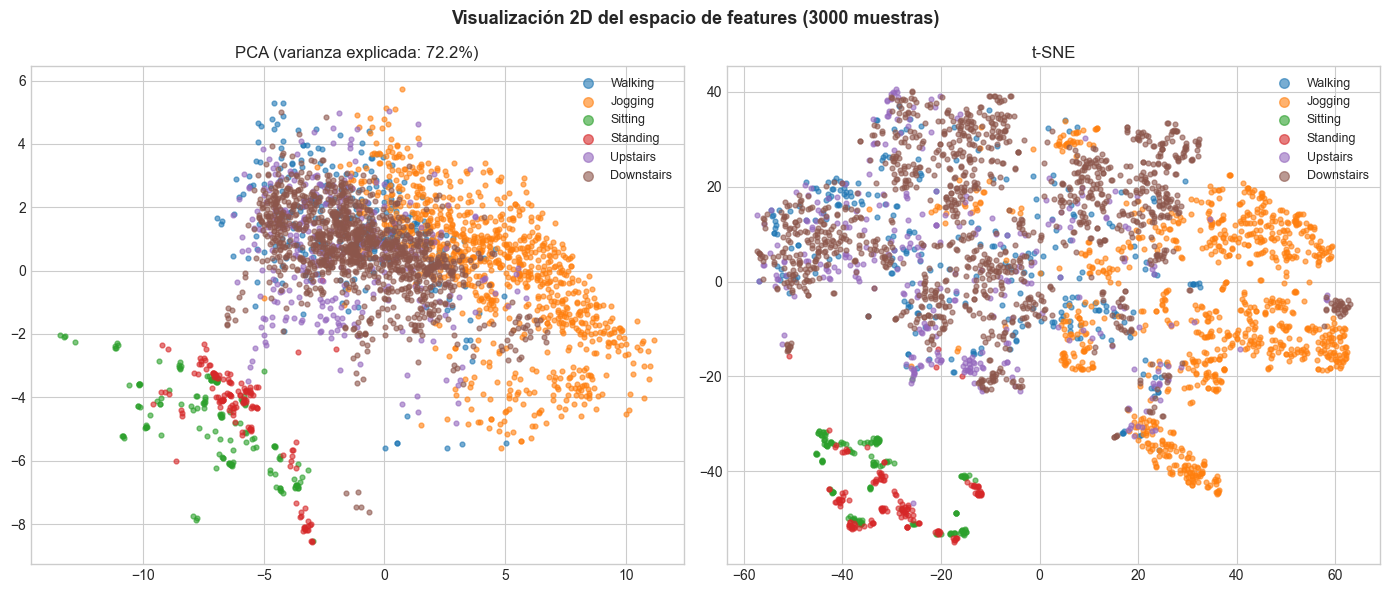


Interpretación t-SNE:
  → Jogging y Walking forman clusters bien definidos
  → Sitting y Standing se solapan parcialmente: actividades estáticas similares
  → Upstairs/Downstairs también tienen cierto solapamiento
  → Anticipamos que la mayor tasa de error estará en clases estáticas


In [10]:
# PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_.sum()

# t-SNE
print('Calculando t-SNE (puede tardar ~1-2 minutos)...')
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, n_iter_without_progress=1000, verbose=0)
X_tsne = tsne.fit_transform(X_scaled)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for act_id in sorted(labels):
    mask = y_sub == act_id
    axes[0].scatter(X_pca[mask, 0],  X_pca[mask, 1],
                    label=labels[act_id], s=12, alpha=0.6)
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    label=labels[act_id], s=12, alpha=0.6)

axes[0].set_title(f'PCA (varianza explicada: {var_exp:.1%})', fontsize=12)
axes[0].legend(markerscale=2, fontsize=9)
axes[1].set_title('t-SNE', fontsize=12)
axes[1].legend(markerscale=2, fontsize=9)

plt.suptitle(f'Visualización 2D del espacio de features ({N_VIZ} muestras)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pca_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('Interpretación t-SNE:')
print('  → Jogging y Walking forman clusters bien definidos')
print('  → Sitting y Standing se solapan parcialmente: actividades estáticas similares')
print('  → Upstairs/Downstairs también tienen cierto solapamiento')
print('  → Anticipamos que la mayor tasa de error estará en clases estáticas')

## 6. Estadísticas descriptivas por clase

In [ ]:
import pandas as pd

stats_rows = []
for act_id in sorted(labels):
    mask = y_train == act_id
    signals = X_train[mask]  # (n, 90, 3)
    magnitude = np.sqrt((signals**2).sum(axis=2))  # (n, 90)
    stats_rows.append({
        'Actividad': labels[act_id],
        'N train': int(mask.sum()),
        'Mag. media': magnitude.mean().round(3),
        'Mag. std':   magnitude.std().round(3),
        'Mag. max':   magnitude.max().round(3),
    })

df_stats = pd.DataFrame(stats_rows).set_index('Actividad')
display(df_stats)

## Conclusiones del EDA

| Hallazgo | Impacto en el modelado |
|----------|------------------------|
| Dataset **desbalanceado** (Jogging 28%, Downstairs 35%) | Métrica principal: **F1-macro** |
| Señal **cruda** (90×3), sin features precalculadas | Para modelos clásicos: extraer features estadísticas manualmente |
| Jogging/Walking → alta varianza y periodicidad clara | Fácilmente clasificables |
| Sitting/Standing → señal casi estática, clusters solapados | Par de clases más difícil |
| Upstairs/Downstairs → señal similar entre sí | Segunda fuente de error esperada |

**Próximo paso:** Extraer 33 features estadísticas (11 × 3 ejes) y entrenar modelos clásicos.